# Production Post-Mortem: The Incident of the Shifting Medians

## The Incident
An e-commerce company deployed a linear regression model to predict customer lifetime value (LTV). During sales events, customers complained that identical checkout baskets were receiving vastly different discounts and LTV scores.

## The Root Cause: Dynamic Batch Imputation
The engineering team built a preprocessing step that imputed missing data (e.g., `days_since_last_login`) on-the-fly using the median of the incoming inference batch.

On normal days, the median was `15` days. During a major promotion, a massive wave of new users logged in (with missing values or `0` days). The batch median shifted to `2` days.

Because the imputation value shifted dynamically, a customer's LTV score would change depending on which other customers happened to be in the same inference batch, creating batch-dependency and prediction drift.

## The Bad Code (Dynamic Batch Imputation)
This section demonstrates the problematic approach where missing values are imputed using the median calculated from the *current* inference batch. This leads to inconsistent results.

In [6]:
import numpy as np
import pandas as pd

# Simulating incoming production inference batches
batch_normal = pd.DataFrame({'days_since_login': [12.0, 15.0, np.nan, 18.0]})
batch_promo = pd.DataFrame({'days_since_login': [0.0, 1.0, np.nan, 2.0, np.nan]})

# --- ANTI-PATTERN: Imputing using the runtime batch median ---
def preprocess_bad(df):
    batch_median = df['days_since_login'].median()
    df_imputed = df.copy()
    df_imputed['days_since_login'] = df_imputed['days_since_login'].fillna(batch_median)
    print(f"DEBUG: Imputed using batch median = {batch_median}")
    return df_imputed

# An identical NaN profile is filled with different values depending on the batch context
res_normal = preprocess_bad(batch_normal)
res_promo = preprocess_bad(batch_promo)

DEBUG: Imputed using batch median = 15.0
DEBUG: Imputed using batch median = 1.0


### Results of Bad Code
Notice how the `NaN` values are imputed with different values (15.0 and 1.0) based on the context of the batch. This creates inconsistent LTV scores for identical customer profiles.

In [7]:
print('Normal Batch Imputation:')
display(res_normal)
print('\nPromotional Batch Imputation:')
display(res_promo)

Normal Batch Imputation:


,days_since_login
0,12.0
1,15.0
2,15.0
3,18.0



Promotional Batch Imputation:


,days_since_login
0,0.0
1,1.0
2,1.0
3,2.0
4,1.0


## The Good Code (Anchored Imputation)
To fix this, we must calculate the median only on the training dataset, serialize this static value as metadata, and lock it in the inference pipeline. This ensures consistency regardless of the incoming batch composition.

In [8]:
import json
import numpy as np
import pandas as pd

# Training phase: Calculate and anchor the median
train_df = pd.DataFrame({'days_since_login': [10.0, 15.0, 12.0, 20.0, 16.0]})
anchored_median = train_df['days_since_login'].median()  # Locked value = 15.0

# Save to metadata JSON config
metadata = {"days_since_login_median": anchored_median}
with open("model_metadata.json", "w") as f:
    json.dump(metadata, f)

# --- PRODUCTION-SAFE PATTERN: Ingestion pipeline load anchored metadata ---
def preprocess_safe(df, metadata_path="model_metadata.json"):
    with open(metadata_path, "r") as f:
        meta = json.load(f)

    impute_value = meta["days_since_login_median"]
    df_imputed = df.copy()
    df_imputed['days_since_login'] = df_imputed['days_since_login'].fillna(impute_value)
    print(f"DEBUG: Imputed using anchored median = {impute_value}")
    return df_imputed

# Both batches now receive consistent imputations (15.0) regardless of the batch composition
res_normal_safe = preprocess_safe(batch_normal)
res_promo_safe = preprocess_safe(batch_promo)

DEBUG: Imputed using anchored median = 15.0
DEBUG: Imputed using anchored median = 15.0


### Results of Good Code
Now, both batches are imputed with the *same* anchored median (15.0), ensuring consistent LTV scores and preventing prediction drift.

In [9]:
print('Normal Batch Imputation (Anchored):')
display(res_normal_safe)
print('\nPromotional Batch Imputation (Anchored):')
display(res_promo_safe)

Normal Batch Imputation (Anchored):


,days_since_login
0,12.0
1,15.0
2,15.0
3,18.0



Promotional Batch Imputation (Anchored):


,days_since_login
0,0.0
1,1.0
2,15.0
3,2.0
4,15.0


## Visualizing the Impact
Let's visualize the `days_since_login` values for both scenarios to clearly see the difference in imputation.

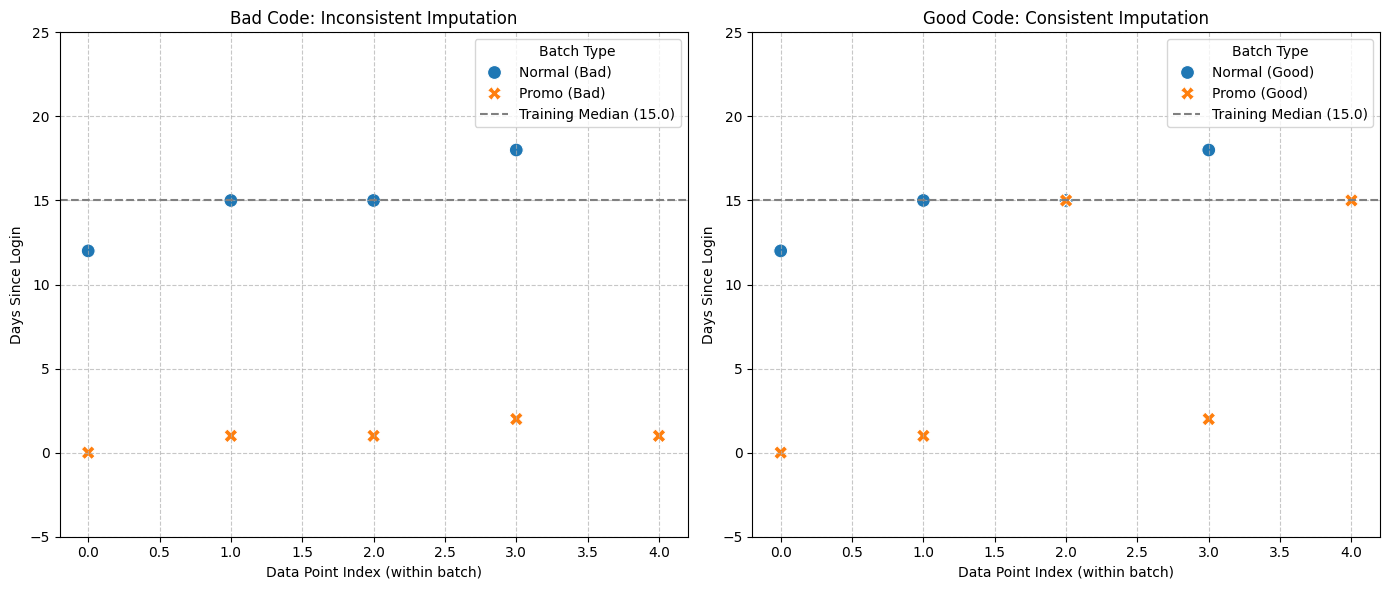

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Plot for Bad Code
plt.subplot(1, 2, 1)

# Combine and label data for plotting
bad_data = pd.concat([
    res_normal.assign(batch='Normal (Bad)', index=res_normal.index),
    res_promo.assign(batch='Promo (Bad)', index=res_promo.index)
])
bad_data['original_index'] = bad_data.groupby('batch').cumcount() # To align points for original data

sns.scatterplot(data=bad_data, x='original_index', y='days_since_login', hue='batch', style='batch', s=100)
plt.title('Bad Code: Inconsistent Imputation')
plt.xlabel('Data Point Index (within batch)')
plt.ylabel('Days Since Login')
plt.ylim(-5, 25)
plt.axhline(y=15, color='gray', linestyle='--', label='Training Median (15.0)')
plt.legend(title='Batch Type')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot for Good Code
plt.subplot(1, 2, 2)

good_data = pd.concat([
    res_normal_safe.assign(batch='Normal (Good)', index=res_normal_safe.index),
    res_promo_safe.assign(batch='Promo (Good)', index=res_promo_safe.index)
])
good_data['original_index'] = good_data.groupby('batch').cumcount()

sns.scatterplot(data=good_data, x='original_index', y='days_since_login', hue='batch', style='batch', s=100)
plt.title('Good Code: Consistent Imputation')
plt.xlabel('Data Point Index (within batch)')
plt.ylabel('Days Since Login')
plt.ylim(-5, 25)
plt.axhline(y=15, color='gray', linestyle='--', label='Training Median (15.0)')
plt.legend(title='Batch Type')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Conclusion
This example vividly demonstrates the importance of anchoring preprocessing steps to static values derived from the training data. Dynamic batch imputation, while seemingly convenient, introduces non-determinism and can lead to prediction drift, eroding trust in machine learning models in production environments. By using an anchored median, we ensure that the imputation is consistent, leading to more reliable and fair model predictions.